# Exploração dos dados e modelo de score

Análise exploratória da camada **Gold** e avaliação do modelo que estima o `SCORE` de crédito.
Todo o processamento vem do pacote `credit_pipeline`, o mesmo código que roda na CLI, no Airflow e no CI.
Para reproduzir: `make install && make run-local`, depois execute este notebook.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from credit_pipeline import ml
from credit_pipeline.config import Paths
from credit_pipeline.gold import CATEGORIAS_RENDA, FAIXAS_ETARIAS
from credit_pipeline.io import read_layer_csv

sns.set_theme(style="whitegrid", palette="crest")
pd.set_option("display.float_format", "{:,.2f}".format)

paths = Paths.from_env()
df = read_layer_csv(paths.gold_dir / "dados_gold.csv")
print(f"{len(df):,} clientes | {df.shape[1]} colunas")

10,476 clientes | 24 colunas


## 1. Visão geral

In [2]:
df[["IDADE", "RENDA_TOTAL", "SCORE", "QT_IMOVEIS", "VL_IMOVEIS", "QT_CARROS", "TEMPO_ULTIMO_EMPREGO_MESES"]].describe().T

,count,mean,std,min,25%,50%,75%,max
IDADE,"10,476.00",41.05,13.88,19.00,28.00,42.00,53.00,65.00
RENDA_TOTAL,"10,476.00","8,927.77","6,242.97","1,800.00","3,900.00","8,500.00","11,500.00","24,400.00"
SCORE,"10,476.00",50.74,27.22,12.00,28.00,45.00,72.00,98.00
QT_IMOVEIS,"10,476.00",0.85,0.96,0.00,0.00,1.00,1.00,3.00
VL_IMOVEIS,"10,476.00","238,453.61","265,843.93",0.00,0.00,"185,000.00","370,000.00","900,000.00"
QT_CARROS,"10,476.00",0.94,0.81,0.00,0.00,1.00,2.00,2.00
TEMPO_ULTIMO_EMPREGO_MESES,"10,476.00",43.07,40.85,8.00,14.00,22.00,75.00,150.00


## 2. Distribuição do score

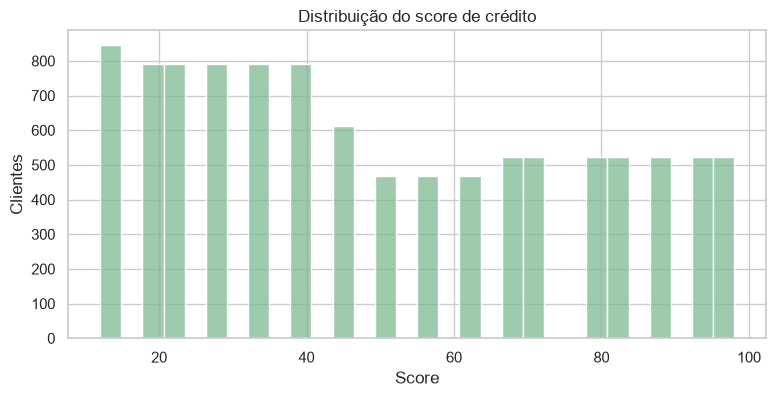

In [3]:
fig, ax = plt.subplots(figsize=(9, 4))
sns.histplot(df["SCORE"], bins=30, ax=ax)
ax.set(title="Distribuição do score de crédito", xlabel="Score", ylabel="Clientes")
plt.show()

## 3. Score por faixa etária e categoria de renda

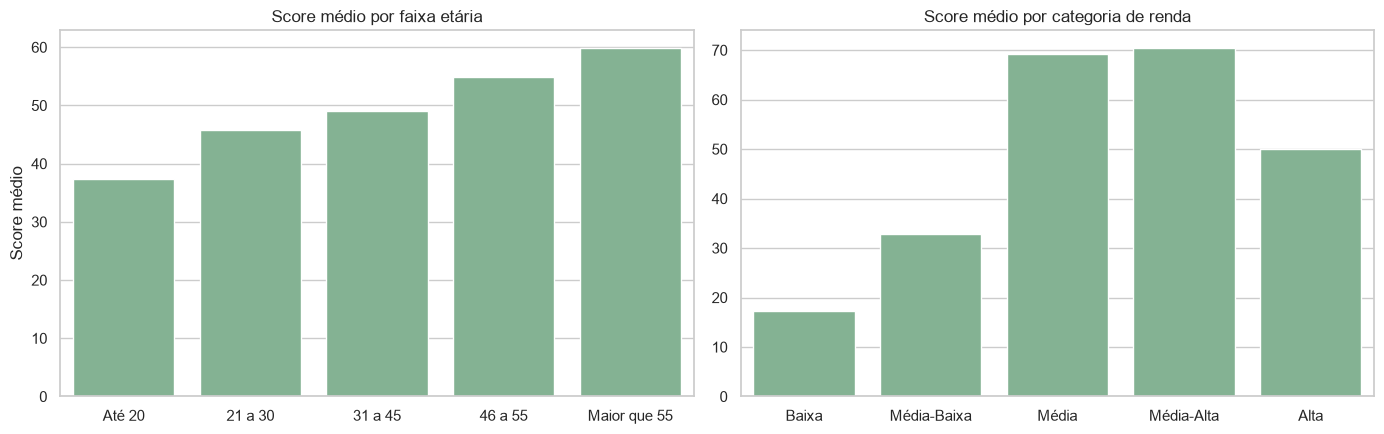

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
sns.barplot(data=df, x="FAIXA_ETARIA", y="SCORE", order=FAIXAS_ETARIAS, errorbar=None, ax=axes[0])
axes[0].set(title="Score médio por faixa etária", xlabel="", ylabel="Score médio")
sns.barplot(data=df, x="CATEGORIA_RENDA", y="SCORE", order=CATEGORIAS_RENDA, errorbar=None, ax=axes[1])
axes[1].set(title="Score médio por categoria de renda", xlabel="", ylabel="")
plt.tight_layout()
plt.show()

## 4. Correlação entre variáveis numéricas

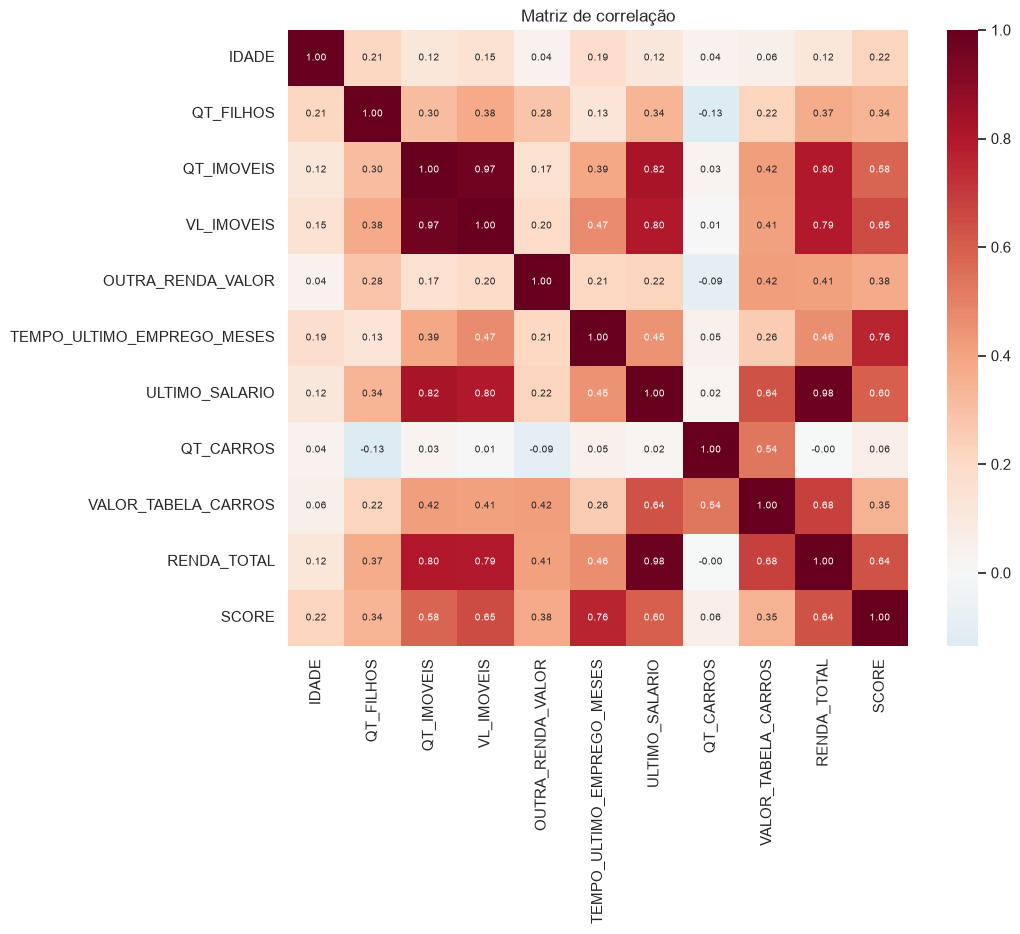

In [5]:
numericas = ["IDADE", "QT_FILHOS", "QT_IMOVEIS", "VL_IMOVEIS", "OUTRA_RENDA_VALOR", "TEMPO_ULTIMO_EMPREGO_MESES",
             "ULTIMO_SALARIO", "QT_CARROS", "VALOR_TABELA_CARROS", "RENDA_TOTAL", "SCORE"]
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(df[numericas].corr(), cmap="RdBu_r", center=0, annot=True, fmt=".2f", annot_kws={"size": 7}, ax=ax)
ax.set_title("Matriz de correlação")
plt.show()

In [6]:
df[numericas].corr()["SCORE"].drop("SCORE").sort_values(ascending=False).to_frame("correlacao_com_score")

,correlacao_com_score
TEMPO_ULTIMO_EMPREGO_MESES,0.76
VL_IMOVEIS,0.65
RENDA_TOTAL,0.64
ULTIMO_SALARIO,0.60
QT_IMOVEIS,0.58
OUTRA_RENDA_VALOR,0.38
VALOR_TABELA_CARROS,0.35
QT_FILHOS,0.34
IDADE,0.22
QT_CARROS,0.06


## 5. Renda e patrimônio versus score

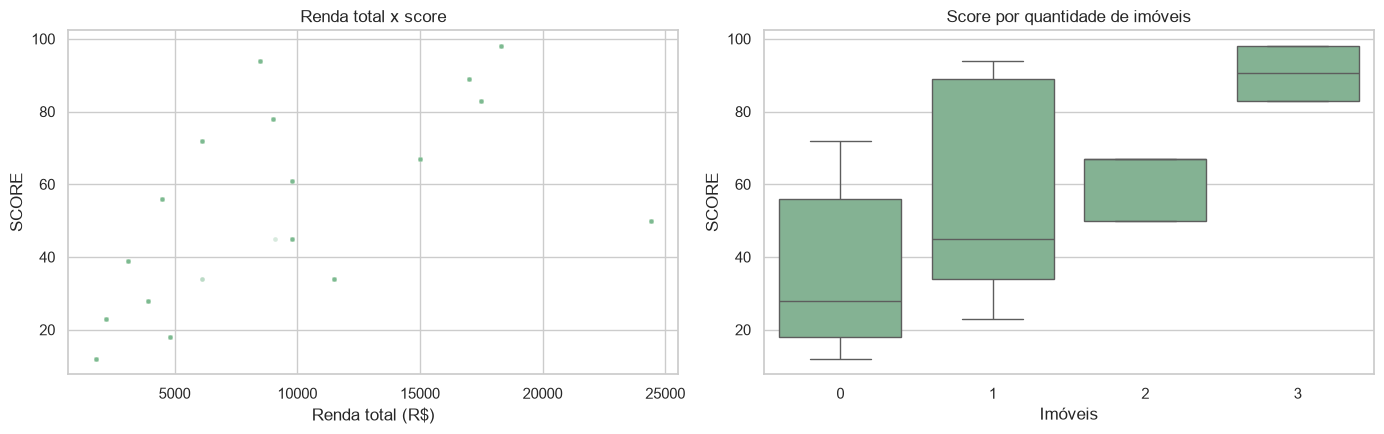

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
sns.scatterplot(data=df, x="RENDA_TOTAL", y="SCORE", alpha=0.3, s=12, ax=axes[0])
axes[0].set(title="Renda total x score", xlabel="Renda total (R$)")
sns.boxplot(data=df, x="QT_IMOVEIS", y="SCORE", ax=axes[1])
axes[1].set(title="Score por quantidade de imóveis", xlabel="Imóveis")
plt.tight_layout()
plt.show()

## 6. Modelo de regressão para o score

Regressão linear com `StandardScaler` nas numéricas e `OneHotEncoder` nas categóricas, avaliada em 30% dos dados
separados para teste. A comparação com um baseline que sempre prevê a média mostra quanto o modelo realmente agrega.

`RENDA_TOTAL` e `OUTRA_RENDA` ficam de fora porque são combinações exatas de outras colunas. Com elas o R² sobe
para ~0,96, mas o modelo passa a usar pares de variáveis que se cancelam, o que torna a interpretação enganosa.

In [8]:
model, metrics = ml.train(df)
pd.DataFrame({"modelo": metrics["modelo"], "baseline (média)": metrics["baseline_media"]})

,modelo,baseline (média)
r2,0.92,-0.00
mae,6.37,24.04
rmse,7.53,27.26


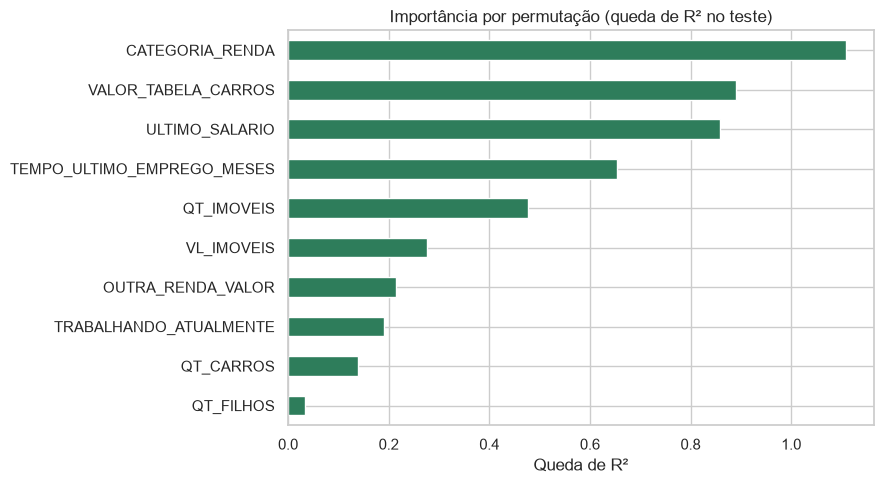

In [9]:
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split

# Importância medida pela queda de R² ao embaralhar cada variável no conjunto de teste.
X, y = ml.prepare(df)
_, X_test, _, y_test = train_test_split(X, y, test_size=ml.TEST_SIZE, random_state=ml.RANDOM_STATE)
importancia = permutation_importance(model, X_test, y_test, scoring="r2", n_repeats=5, random_state=0)
importancia = pd.Series(importancia.importances_mean, index=X_test.columns).sort_values().tail(10)

fig, ax = plt.subplots(figsize=(9, 5))
importancia.plot.barh(ax=ax, color="#2E7D5B")
ax.set(title="Importância por permutação (queda de R² no teste)", xlabel="Queda de R²")
plt.tight_layout()
plt.show()

## 7. Conclusões

- **Tempo no último emprego é o sinal numérico mais forte** do score (correlação de 0,76), seguido de valor dos imóveis e renda total.
- **A relação com renda não é linear**: clientes de renda *Média* e *Média-Alta* têm score maior que os de renda *Alta*. Por isso a `CATEGORIA_RENDA` criada na camada Gold é a feature mais importante do modelo. Sem as features derivadas da Gold, o R² cai de 0,92 para 0,80.
- **O score cresce com a idade** de forma consistente em todas as faixas.
- O modelo explica **92% da variância** do score no conjunto de teste (MAE de ~6 pontos numa escala de 0 a 100), contra 0% do baseline.

**Ressalva:** a base é didática e tem muitos perfis repetidos, então essas métricas não se transfeririam diretamente para dados reais. Próximos passos seriam validação cruzada, um modelo não linear (ex.: gradient boosting) e monitoramento de drift.